# GIS / GeoPandas

In [8]:
import geopandas as gpd
import pandas as pd  


In [3]:
import pandas as pd

df = pd.read_csv("/Users/robertwrobel/Documents/sales_by_zip_2.csv")
df.head()

,Delivery Date,Buyer Postal Code,ZIP,Inventory Type,Total Gross Profit,Back Gross Profit,Front Gross Profit,Trade1 ACV,Trade
0,1/8/25,62012,62012,N,5166.68,2400.58,2407.10,24500.0,1
1,1/3/25,63366,63366,U,5138.11,3621.28,1157.83,NaN,0
2,1/2/25,620241139,62024,N,5781.27,2412.27,3010.00,8500.0,1
3,1/4/25,620751147,62075,U,2687.95,1833.11,495.84,NaN,0
4,1/3/25,630342060,63034,U,6802.83,2638.00,3805.83,16400.0,1


In [4]:
df["ZIP"] = df["Buyer Postal Code"].astype(str).str[:5]

In [5]:
summary = (
    df
    .groupby('ZIP', as_index=False)
    .agg(
        sales=('ZIP','size'),
        total_gross=('Total Gross Profit', 'sum'),
        average_gross=('Total Gross Profit', 'mean'),
        average_front=('Front Gross Profit', 'mean'),
        average_back=('Back Gross Profit', 'mean'),
        total_front=('Front Gross Profit', 'sum'),
        total_back=('Back Gross Profit', 'sum')
    )
)
summary
#summary.to_csv("zipsparsed.csv", index=False)

,ZIP,sales,total_gross,average_gross,average_front,average_back,total_front,total_back
0,28163,1,5482.26,5482.26,513.60,4609.66,513.60,4609.66
1,30062,1,2374.53,2374.53,1814.53,201.00,1814.53,201.00
2,32566,1,2361.50,2361.50,2002.50,0.00,2002.50,0.00
3,33496,1,1581.99,1581.99,1222.99,0.00,1222.99,0.00
4,34242,1,2099.65,2099.65,1411.65,329.00,1411.65,329.00
...,...,...,...,...,...,...,...,...
299,84405,1,1163.18,1163.18,192.15,612.03,192.15,612.03
300,85050,1,1465.65,1465.65,905.65,201.00,905.65,201.00
301,92082,1,2389.91,2389.91,2030.91,0.00,2030.91,0.00
302,93306,1,1041.47,1041.47,481.47,201.00,481.47,201.00


In [9]:
gdf = gpd.read_file("/Users/robertwrobel/Downloads/tl_2025_us_zcta520/tl_2025_us_zcta520.shp")
gdf.head()
gdf.columns
gdf.crs
gdf.geometry.isna().sum()
gdf.geom_type.value_counts().head()
gdf.columns


Index(['ZCTA5CE20', 'GEOID20', 'GEOIDFQ20', 'CLASSFP20', 'MTFCC20',
       'FUNCSTAT20', 'ALAND20', 'AWATER20', 'INTPTLAT20', 'INTPTLON20',
       'geometry'],
      dtype='object')

In [10]:
df["ZIP"] = df["ZIP"].astype(str).str.zfill(5)


In [11]:
zcta_col = "ZCTA5CE20"  
gdf[zcta_col] = gdf[zcta_col].astype(str).str.zfill(5)

In [12]:
m = gdf.merge(summary, left_on=zcta_col, right_on="ZIP", how="left")
m["sales"] = m["sales"].fillna(0)


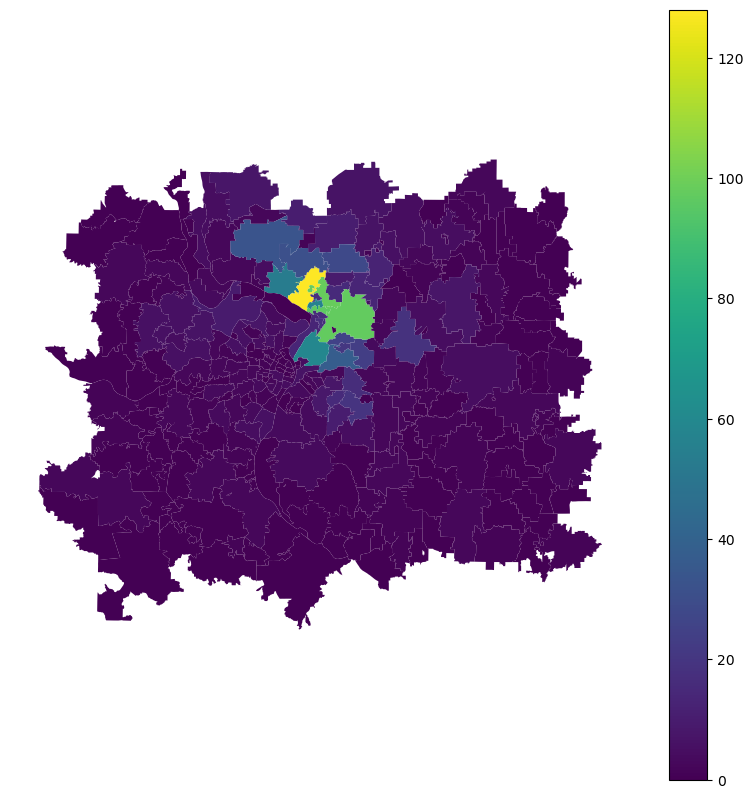

In [13]:
#rough bbox around STL metro
m_stl = m.cx[-91.0:-89.0, 38.0:39.2]
ax = m_stl.plot(column="sales", legend=True, figsize=(10,10))
ax.set_axis_off()




/opt/anaconda3/lib/python3.13/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 2.
  self.bins = quantile(y, k=k)


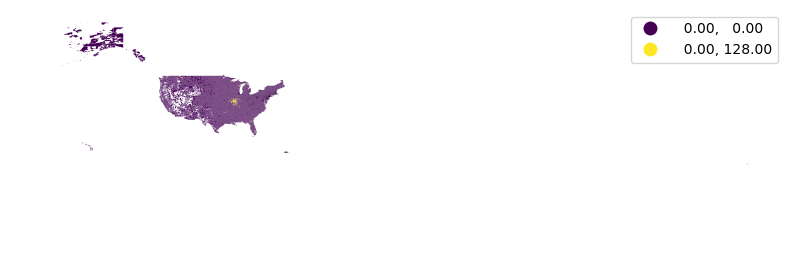

In [14]:
ax = m.plot(
    column="sales",
    scheme="quantiles",  #or "natural_breaks" / "equal_interval" / "quantiles"
    k=5,
    legend=True,
    figsize=(10,10),
)
ax.set_axis_off()


In [ ]:
import folium

m_wgs = m.to_crs(4326)
center = [m_wgs.geometry.centroid.y.mean(), m_wgs.geometry.centroid.x.mean()]

mp = folium.Map(location=center, zoom_start=8, tiles="cartodbpositron")
folium.Choropleth(
    geo_data=m_wgs,
    data=m_wgs,
    columns=[zcta_col, "sales"],
    key_on=f"feature.properties.{zcta_col}",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Count",
).add_to(mp)

mp


/var/folders/6t/1_v9ync132lgs0k2f0d3t9mc0000gn/T/ipykernel_15537/1038045243.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center = [m_wgs.geometry.centroid.y.mean(), m_wgs.geometry.centroid.x.mean()]
